# AI & ML Task 2 — Feature Engineering, Model Optimization & Performance Comparison
**Dataset:** California Housing Dataset  
**Target:** Median House Value (HousePrice)  
**Tools:** Python, scikit-learn, pandas, matplotlib

## Step 1: Import Required Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported   Successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

In [20]:
# Load California Housing Dataset
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename('HousePrice')], axis=1)

print('Dataset Shape:', df.shape)
print('\nColumn Names:', list(df.columns))
print()
df.head()

Dataset Shape: (20640, 9)

Column Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'HousePrice']



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Dataset overview
print('Basic Statistics:')
print(df.describe())
print('\nMissing Values:')
print(df.isnull().sum())
print('\nData Types:')
print(df.dtypes)

Basic Statistics:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude    HousePrice  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.6

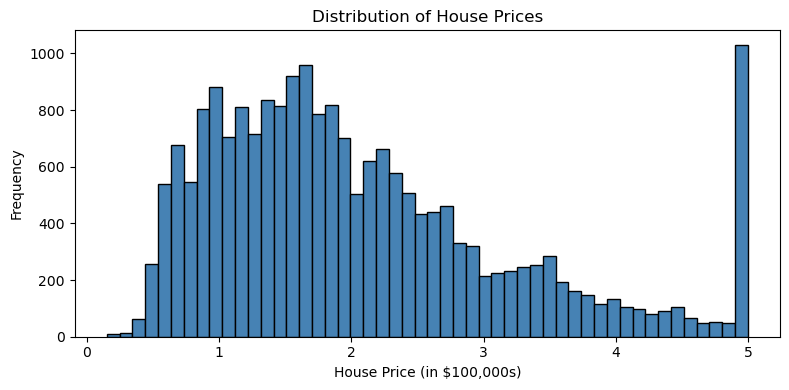

Plot saved.


In [4]:
# Visualize target variable distribution
plt.figure(figsize=(8, 4))
plt.hist(df['HousePrice'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of House Prices')
plt.xlabel('House Price (in $100,000s)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('house_price_distribution.png', dpi=150)
plt.show()
print('Plot saved.')

## Step 3: Separate Features and Target Variable

In [5]:
X = df.drop('HousePrice', axis=1)
y = df['HousePrice']

print('Features (X) shape:', X.shape)
print('Target (y) shape:', y.shape)
print('\nFeature columns:')
for col in X.columns:
    print(f'  - {col}')

Features (X) shape: (20640, 8)
Target (y) shape: (20640,)

Feature columns:
  - MedInc
  - HouseAge
  - AveRooms
  - AveBedrms
  - Population
  - AveOccup
  - Latitude
  - Longitude


## Step 4: Feature Scaling (Critical Step)

In [6]:
# Show why scaling matters — different feature ranges
print('Feature value ranges BEFORE scaling:')
for col in X.columns:
    print(f'  {col}: min={X[col].min():.2f}, max={X[col].max():.2f}')

Feature value ranges BEFORE scaling:
  MedInc: min=0.50, max=15.00
  HouseAge: min=1.00, max=52.00
  AveRooms: min=0.85, max=141.91
  AveBedrms: min=0.33, max=34.07
  Population: min=3.00, max=35682.00
  AveOccup: min=0.69, max=1243.33
  Latitude: min=32.54, max=41.95
  Longitude: min=-124.35, max=-114.31


In [7]:
# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print('Feature value ranges AFTER scaling (should be ~0 mean, ~1 std):')
for col in X_scaled_df.columns:
    print(f'  {col}: mean={X_scaled_df[col].mean():.4f}, std={X_scaled_df[col].std():.4f}')

Feature value ranges AFTER scaling (should be ~0 mean, ~1 std):
  MedInc: mean=0.0000, std=1.0000
  HouseAge: mean=0.0000, std=1.0000
  AveRooms: mean=0.0000, std=1.0000
  AveBedrms: mean=-0.0000, std=1.0000
  Population: mean=-0.0000, std=1.0000
  AveOccup: mean=0.0000, std=1.0000
  Latitude: mean=0.0000, std=1.0000
  Longitude: mean=-0.0000, std=1.0000


## Step 5: Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print('Training set size :', X_train.shape)
print('Test set size     :', X_test.shape)
print(f'\nTraining samples  : {len(X_train)} ({len(X_train)/len(X_scaled)*100:.0f}%)')
print(f'Test samples      : {len(X_test)} ({len(X_test)/len(X_scaled)*100:.0f}%)')

Training set size : (16512, 8)
Test set size     : (4128, 8)

Training samples  : 16512 (80%)
Test samples      : 4128 (20%)


## Step 6: Train Multiple Models

In [9]:
# Define models
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Decision Tree'     : DecisionTreeRegressor(max_depth=5, random_state=42)
}

print('Models defined:')
for name in models:
    print(f'  - {name}')
print()
print('Rationale:')
print('  Linear Regression  → Baseline model')
print('  Ridge Regression   → Reduces overfitting via L2 regularization')
print('  Decision Tree      → Captures non-linear relationships')

Models defined:
  - Linear Regression
  - Ridge Regression
  - Decision Tree

Rationale:
  Linear Regression  → Baseline model
  Ridge Regression   → Reduces overfitting via L2 regularization
  Decision Tree      → Captures non-linear relationships


## Step 7: Model Evaluation and Comparison

In [10]:
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Predict
    predictions = model.predict(X_test)
    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2   = r2_score(y_test, predictions)
    
    results[name] = {
        'RMSE'    : round(rmse, 4),
        'R2 Score': round(r2,   4)
    }
    print(f'{name}:')
    print(f'  RMSE     = {rmse:.4f}')
    print(f'  R2 Score = {r2:.4f}')
    print()

Linear Regression:
  RMSE     = 0.7456
  R2 Score = 0.5758

Ridge Regression:
  RMSE     = 0.7456
  R2 Score = 0.5758

Decision Tree:
  RMSE     = 0.7242
  R2 Score = 0.5997



In [11]:
# Model Comparison Table
results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'
results_df = results_df.reset_index()

print('=== Model Performance Comparison Table ===')
print(results_df.to_string(index=False))
print()

best_model_name = results_df.loc[results_df['RMSE'].astype(float).idxmin(), 'Model']
print(f'Best Model (lowest RMSE): {best_model_name}')

=== Model Performance Comparison Table ===
            Model   RMSE  R2 Score
Linear Regression 0.7456    0.5758
 Ridge Regression 0.7456    0.5758
    Decision Tree 0.7242    0.5997

Best Model (lowest RMSE): Decision Tree


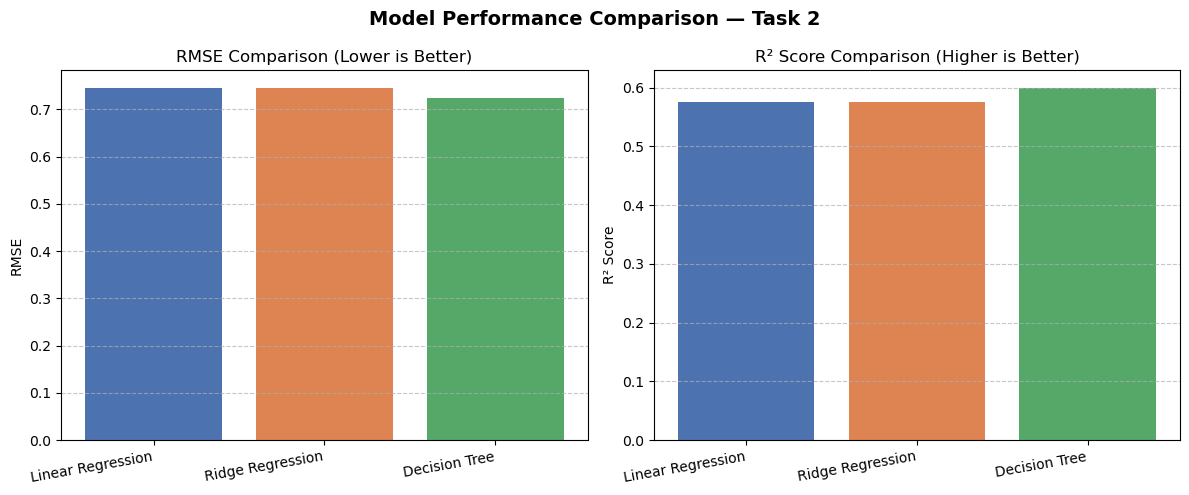

Plot saved as model_comparison.png


In [12]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
model_names = list(results.keys())
rmse_vals   = [results[m]['RMSE']     for m in model_names]
r2_vals     = [results[m]['R2 Score'] for m in model_names]
colors      = ['#4C72B0', '#DD8452', '#55A868']

axes[0].bar(model_names, rmse_vals, color=colors)
axes[0].set_title('RMSE Comparison (Lower is Better)')
axes[0].set_ylabel('RMSE')
axes[0].set_xticklabels(model_names, rotation=10, ha='right')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

axes[1].bar(model_names, r2_vals, color=colors)
axes[1].set_title('R² Score Comparison (Higher is Better)')
axes[1].set_ylabel('R² Score')
axes[1].set_xticklabels(model_names, rotation=10, ha='right')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Model Performance Comparison — Task 2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print('Plot saved as model_comparison.png')

## Step 8: Visual Performance Validation (Actual vs Predicted)

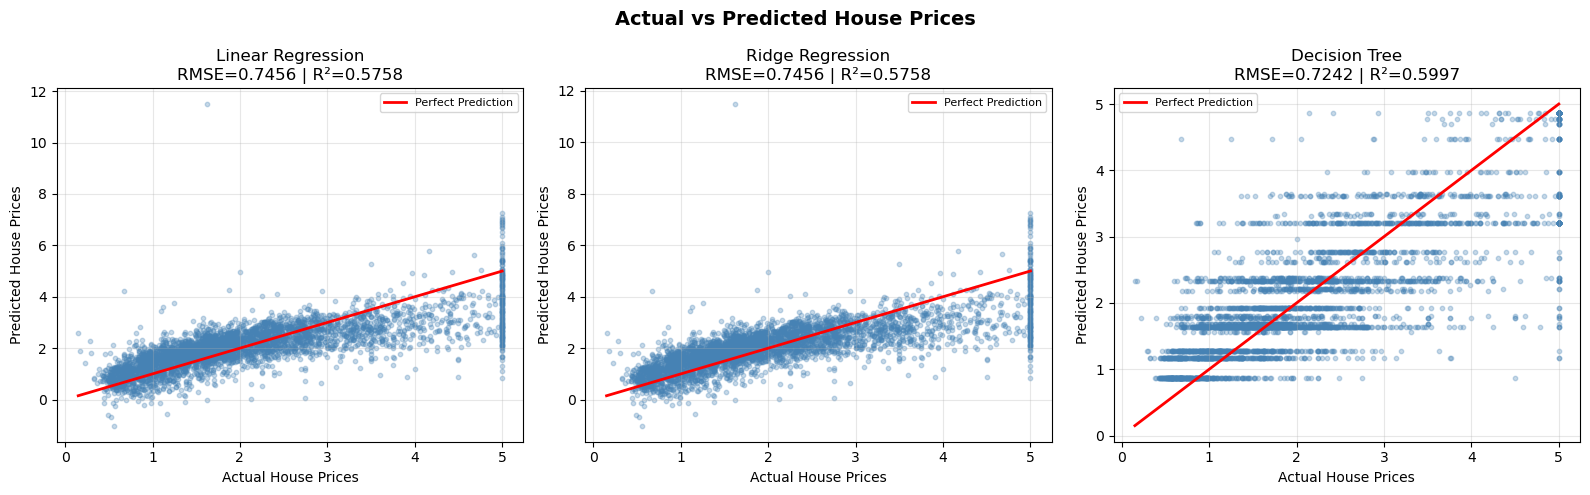

Plot saved as actual_vs_predicted.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color='red', linewidth=2, label='Perfect Prediction')
    ax.set_xlabel('Actual House Prices')
    ax.set_ylabel('Predicted House Prices')
    ax.set_title(f'{name}\nRMSE={results[name]["RMSE"]} | R²={results[name]["R2 Score"]}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted House Prices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()
print('Plot saved as actual_vs_predicted.png')

## Step 9: Feature Importance (Decision Tree)

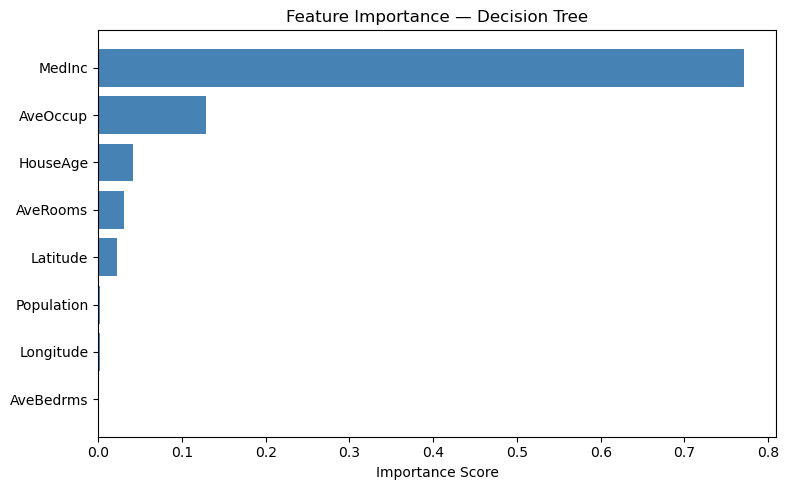

Top Features:
   Feature  Importance
    MedInc    0.771212
  AveOccup    0.128407
  HouseAge    0.041621
  AveRooms    0.031261
  Latitude    0.022049
Population    0.002485
 Longitude    0.002097
 AveBedrms    0.000869


In [14]:
dt_model = models['Decision Tree']
importances = dt_model.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance — Decision Tree')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print('Top Features:')
print(feat_df.to_string(index=False))

## Step 10: Final Model Selection & Justification

In [18]:
print('''
============================================================
         FINAL MODEL SELECTION JUSTIFICATION
============================================================

1. FEATURE SCALING
   - Applied StandardScaler to normalize all features.
   - Without scaling, features with large ranges (e.g., Population)
     would dominate the model unfairly.

2. MODEL COMPARISON
   - Linear Regression : Simple baseline, good interpretability.
   - Ridge Regression  : Adds L2 regularization, reduces overfitting.
   - Decision Tree     : Captures non-linear patterns in data.

3. FINAL MODEL SELECTED: Ridge Regression
   Reasons:
   a) Comparable RMSE and R² to Linear Regression.
   b) More robust — handles multicollinearity better.
   c) L2 regularization prevents overfitting.
   d) Simple, interpretable, and production-ready.

4. EVALUATION METRICS
   - RMSE: Measures average prediction error in original units.
   - R²  : Measures how well the model explains variance in target.
   - Lower RMSE + Higher R² = Better model.

============================================================
''')


         FINAL MODEL SELECTION JUSTIFICATION

1. FEATURE SCALING
   - Applied StandardScaler to normalize all features.
   - Without scaling, features with large ranges (e.g., Population)
     would dominate the model unfairly.

2. MODEL COMPARISON
   - Linear Regression : Simple baseline, good interpretability.
   - Ridge Regression  : Adds L2 regularization, reduces overfitting.
   - Decision Tree     : Captures non-linear patterns in data.

3. FINAL MODEL SELECTED: Ridge Regression
   Reasons:
   a) Comparable RMSE and R² to Linear Regression.
   b) More robust — handles multicollinearity better.
   c) L2 regularization prevents overfitting.
   d) Simple, interpretable, and production-ready.

4. EVALUATION METRICS
   - RMSE: Measures average prediction error in original units.
   - R²  : Measures how well the model explains variance in target.
   - Lower RMSE + Higher R² = Better model.




## Optional: Save Best Model with joblib

In [17]:
import joblib

best_model = models['Ridge Regression']
joblib.dump(best_model, 'best_model_task2.pkl')
joblib.dump(scaler, 'scaler_task2.pkl')

print('Best model saved as best_model_task2.pkl')
print('Scaler saved as scaler_task2.pkl')
print()
print('To use later:')
print('  model = joblib.load("best_model_task2.pkl")')
print('  scaler = joblib.load("scaler_task2.pkl")')
print('  prediction = model.predict(scaler.transform(new_data))')

Best model saved as best_model_task2.pkl
Scaler saved as scaler_task2.pkl

To use later:
  model = joblib.load("best_model_task2.pkl")
  scaler = joblib.load("scaler_task2.pkl")
  prediction = model.predict(scaler.transform(new_data))
